In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Read data（当前特征：包含 Max Intensity 在内的全部物理特征）
file_path = '副本用于机器学习(2).csv'
df = pd.read_csv(file_path)

# 删除空列（如导出时自动生成的 Unnamed 列）及全 NaN 列，确保无缺失值进入模型
drop_cols = [c for c in df.columns if (str(c).startswith('Unnamed') or df[c].isna().all())]
df = df.drop(columns=drop_cols, errors='ignore')

# 当前用于学习的特征（除 Category 外的所有列，包括 Max Intensity 和 Peak-to-peak difference）
feature_cols = [c for c in df.columns if c != 'Category']
print("Data shape:", df.shape)
print("Features used (当前特征，含 Max Intensity):", feature_cols)
print("\nFirst 5 rows:")
print(df.head())
print("\nClass distribution:")
print(df['Category'].value_counts())

Data shape: (81, 8)
Features used (当前特征，含 Max Intensity): ['Concentration', 'Max Intensity', 'Peak Pos', 'FWHM', 'The width at the base of the peak', 'Peak Area', 'Skewness']

First 5 rows:
  Category  Concentration  Max Intensity  Peak Pos      FWHM  \
0       Rn           2000         0.5273     1.374  0.359712   
1       Rn           2000         0.5448     1.350  0.801600   
2       Rn           2000         0.6412     1.269  0.273600   
3       Rn           2000         0.5785     1.340  0.001000   
4       Rn            100         0.1771     1.384  0.367432   

   The width at the base of the peak  Peak Area  Skewness  
0                           0.630656     0.3849  0.353589  
1                           1.073616     0.3539 -0.455102  
2                           1.128461     0.2557 -0.438607  
3                           0.645252     0.0903  0.395456  
4                           0.673587     0.0222  0.401481  

Class distribution:
Category
Xe    45
Rn    36
Name: count, dtyp

In [29]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# 使用当前全部特征重新学习与预测（含 Max Intensity、Peak-to-peak difference 等）
X = df.drop(columns=['Category']).copy()
y = df['Category'].copy()
print("当前用于学习的特征:", list(X.columns))
print("特征数:", X.shape[1], "\n")

# 严格划分训练/测试（测试集后续不参与任何拟合或调参）
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =====================
# 模型A：逻辑回归（L1/L2 正则）
# =====================
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=5000))
])

param_lr = {
    'clf__solver': ['saga'],
    'clf__penalty': ['l1', 'l2'],
    'clf__C': np.logspace(-3, 3, 13),
    'clf__class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    pipe_lr,
    param_grid=param_lr,
    cv=cv,
    n_jobs=-1,
    scoring='accuracy'
)

grid_lr.fit(X_train, y_train)

print('=== Leakage-safe LogisticRegression (regularized) ===')
print('Best CV accuracy:', grid_lr.best_score_)
print('Best params:', grid_lr.best_params_)

y_pred_lr = grid_lr.predict(X_test)
print('Test accuracy:', accuracy_score(y_test, y_pred_lr))
print('Test report:\n', classification_report(y_test, y_pred_lr))

# =====================
# 模型B：SVM（C 为正则强度，配合标准化）
# =====================
pipe_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC())
])

param_svc = [
    {
        'clf__kernel': ['linear'],
        'clf__C': np.logspace(-3, 3, 13),
        'clf__class_weight': [None, 'balanced']
    },
    {
        'clf__kernel': ['rbf'],
        'clf__C': np.logspace(-3, 3, 13),
        'clf__gamma': ['scale', 'auto'],
        'clf__class_weight': [None, 'balanced']
    }
]

grid_svc = GridSearchCV(
    pipe_svc,
    param_grid=param_svc,
    cv=cv,
    n_jobs=-1,
    scoring='accuracy'
)

grid_svc.fit(X_train, y_train)

print('\n=== Leakage-safe SVC (regularized via C) ===')
print('Best CV accuracy:', grid_svc.best_score_)
print('Best params:', grid_svc.best_params_)

y_pred_svc = grid_svc.predict(X_test)
print('Test accuracy:', accuracy_score(y_test, y_pred_svc))
print('Test report:\n', classification_report(y_test, y_pred_svc))


当前用于学习的特征: ['Concentration', 'Max Intensity', 'Peak Pos', 'FWHM', 'The width at the base of the peak', 'Peak Area', 'Skewness']
特征数: 7 

=== Leakage-safe LogisticRegression (regularized) ===
Best CV accuracy: 0.9846153846153847
Best params: {'clf__C': 1.0, 'clf__class_weight': None, 'clf__penalty': 'l1', 'clf__solver': 'saga'}
Test accuracy: 1.0
Test report:
               precision    recall  f1-score   support

          Rn       1.00      1.00      1.00         8
          Xe       1.00      1.00      1.00         9

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17


=== Leakage-safe SVC (regularized via C) ===
Best CV accuracy: 0.9692307692307693
Best params: {'clf__C': 0.03162277660168379, 'clf__class_weight': None, 'clf__kernel': 'linear'}
Test accuracy: 1.0
Test report:
               precision    recall  f1-score   support

          Rn       1.00      1.00      1.00

5-Fold Cross Validation (mean ± std)
              Model  accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  recall_std  f1_mean  f1_std  roc_auc_mean  roc_auc_std
          SVM (RBF)         0.9640        0.0474          0.9778         0.0444       0.9556      0.0544   0.9660  0.0448        0.9972       0.0056
      Random Forest         1.0000        0.0000          1.0000         0.0000       1.0000      0.0000   1.0000  0.0000        1.0000       0.0000
Logistic Regression         0.9632        0.0300          0.9400         0.0490       1.0000      0.0000   0.9684  0.0258        0.9937       0.0127


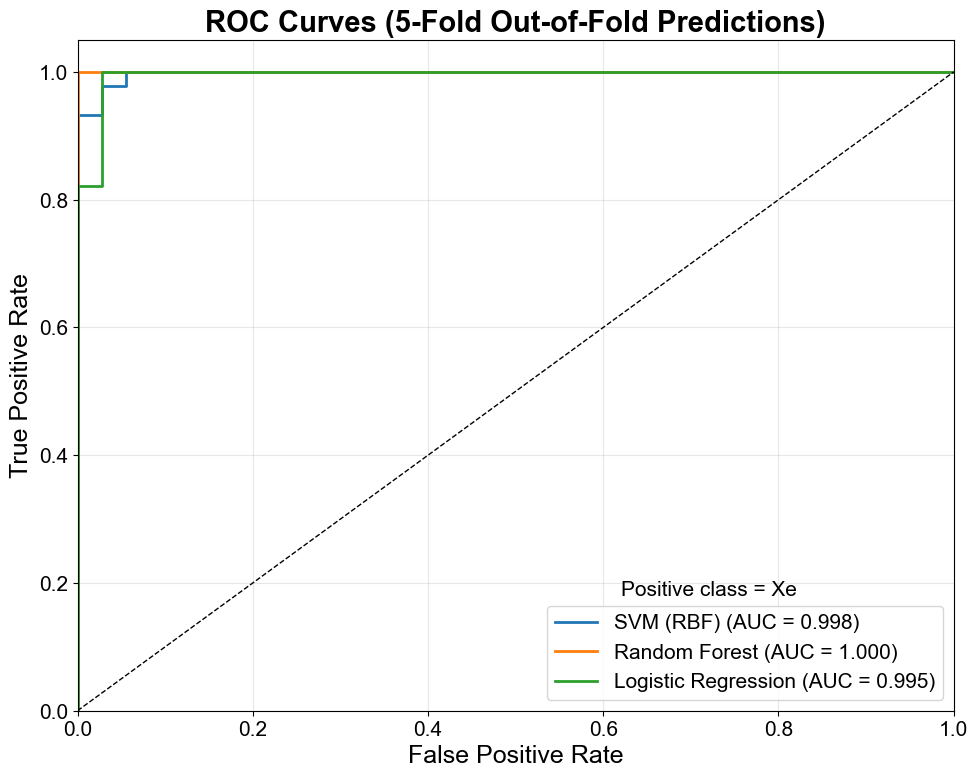

In [30]:
# ==========================================
# 6. 三个模型的 ROC 曲线 + 五折交叉验证
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# 统一字体（与前面热图一致）
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'

# ---------- 数据 ----------
X = df.drop('Category', axis=1)
y = df['Category']

# ROC 需要二分类的 0/1 标签
le = LabelEncoder()
y_bin = le.fit_transform(y)  # 0/1
class_names = list(le.classes_)

# ---------- 模型（用 Pipeline 确保 CV 中不泄漏标准化） ----------
models = {
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, random_state=42))
    ])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------- 五折交叉验证（多指标） ----------
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X, y_bin, cv=cv, scoring=scoring)
    row = {'Model': name}
    for k in scoring.keys():
        vals = scores[f'test_{k}']
        row[f'{k}_mean'] = float(np.mean(vals))
        row[f'{k}_std'] = float(np.std(vals))
    cv_rows.append(row)

cv_df = pd.DataFrame(cv_rows)
print('5-Fold Cross Validation (mean ± std)')
print(cv_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# ---------- ROC 曲线（基于 out-of-fold 预测） ----------
plt.figure(figsize=(10, 8))

for name, model in models.items():
    # 交叉验证下的样本级预测概率（out-of-fold）
    y_proba = cross_val_predict(model, X, y_bin, cv=cv, method='predict_proba')[:, 1]

    fpr, tpr, _ = roc_curve(y_bin, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=18, fontfamily='Arial')
plt.ylabel('True Positive Rate', fontsize=18, fontfamily='Arial')
plt.title('ROC Curves (5-Fold Out-of-Fold Predictions)', fontsize=21, fontweight='bold', fontfamily='Arial')
plt.legend(loc='lower right', fontsize=15)
plt.grid(alpha=0.3)

# 备注：LabelEncoder 的正类是 class_names[1]
plt.text(0.62, 0.18, f'Positive class = {class_names[1]}', fontsize=15)

plt.tick_params(axis='both', labelsize=15)
plt.tight_layout(pad=1.5)
plt.show()

In [18]:
# 安装 SHAP（如已安装可跳过）
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "shap"])

# 安装后如仍报错，请 Kernel 重启后再运行后续单元格

0

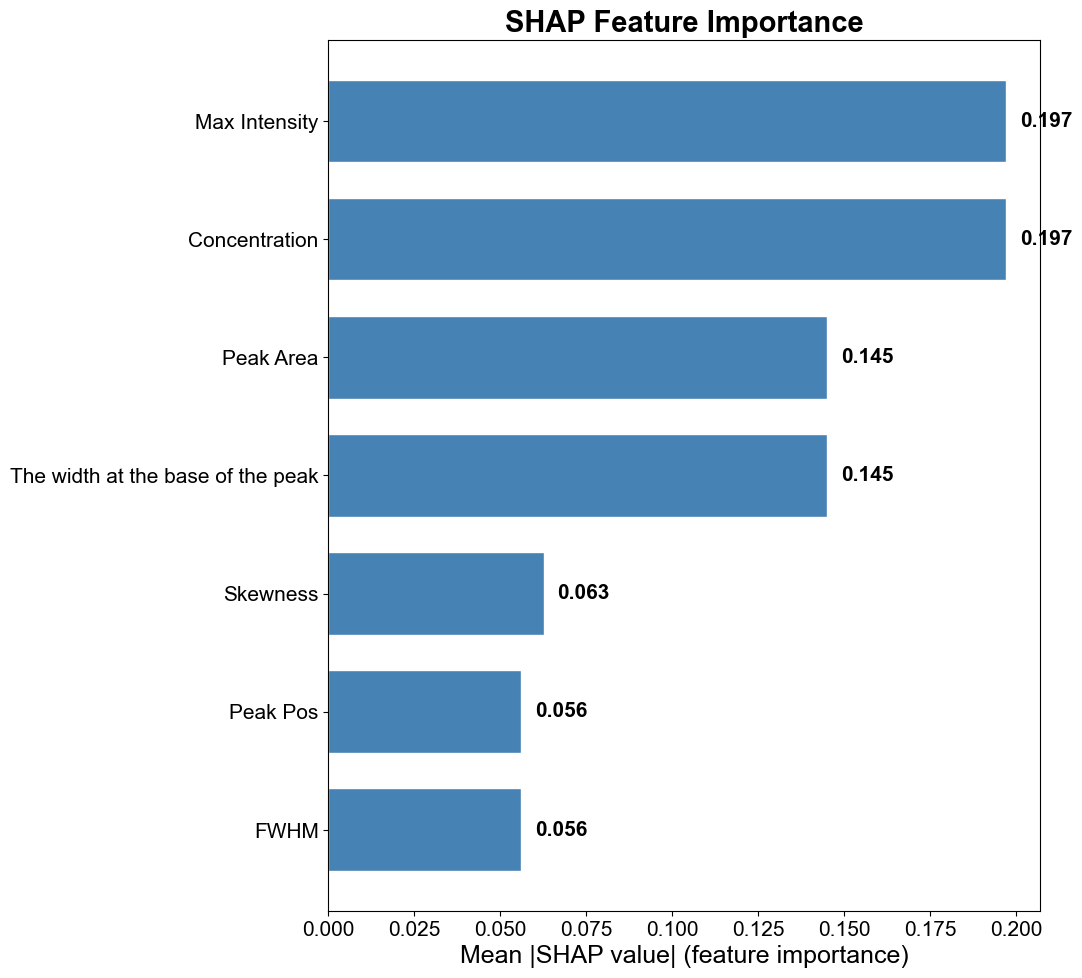

In [19]:
# ==========================================
# SHAP 特征重要性（小样本专用：一张图清晰展示各特征 importance）
# 需先运行第 1 格加载 df，以及上一格安装 shap
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 数据划分
X = df.drop(columns=['Category']).copy()
y = df['Category'].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 训练随机森林
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# 小样本建议：在训练集上计算 SHAP，样本更多、重要性更稳定
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]  # 二分类取正类
else:
    shap_vals = shap_values

# 各特征的平均 |SHAP|（即全局特征重要性），保证为 1D 且与特征数一致
feature_names = list(X.columns)
n_features = len(feature_names)
mean_abs = np.asarray(np.mean(np.abs(shap_vals), axis=0)).flatten()
if len(mean_abs) > n_features:
    mean_abs = mean_abs[:n_features]
elif len(mean_abs) < n_features:
    mean_abs = np.pad(mean_abs.astype(float), (0, n_features - len(mean_abs)), constant_values=0)
# 按重要性从高到低排序
order = np.atleast_1d(np.argsort(mean_abs)[::-1]).astype(int)
names_sorted = [feature_names[int(i)] for i in order]
values_sorted = mean_abs[order]

# 一张图：横向条形图 + 每根条上标数值，便于小样本下清晰对比
fig, ax = plt.subplots(figsize=(11, 10))
y_pos = np.arange(len(names_sorted))
bars = ax.barh(y_pos, values_sorted, color='steelblue', edgecolor='white', height=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(names_sorted, fontsize=17)
ax.set_xlabel('Mean |SHAP value| (feature importance)', fontsize=18)
ax.set_title('SHAP Feature Importance', fontsize=21, fontweight='bold')
ax.tick_params(axis='both', labelsize=15)
ax.invert_yaxis()  # 最重要在顶部

# 在每根条末端标数值，便于精确对比
for i, (bar, v) in enumerate(zip(bars, values_sorted)):
    ax.text(v + values_sorted.max() * 0.02, bar.get_y() + bar.get_height() / 2,
            f'{v:.3f}', va='center', fontsize=15, fontweight='bold')

plt.tight_layout(pad=1.5)
plt.show()

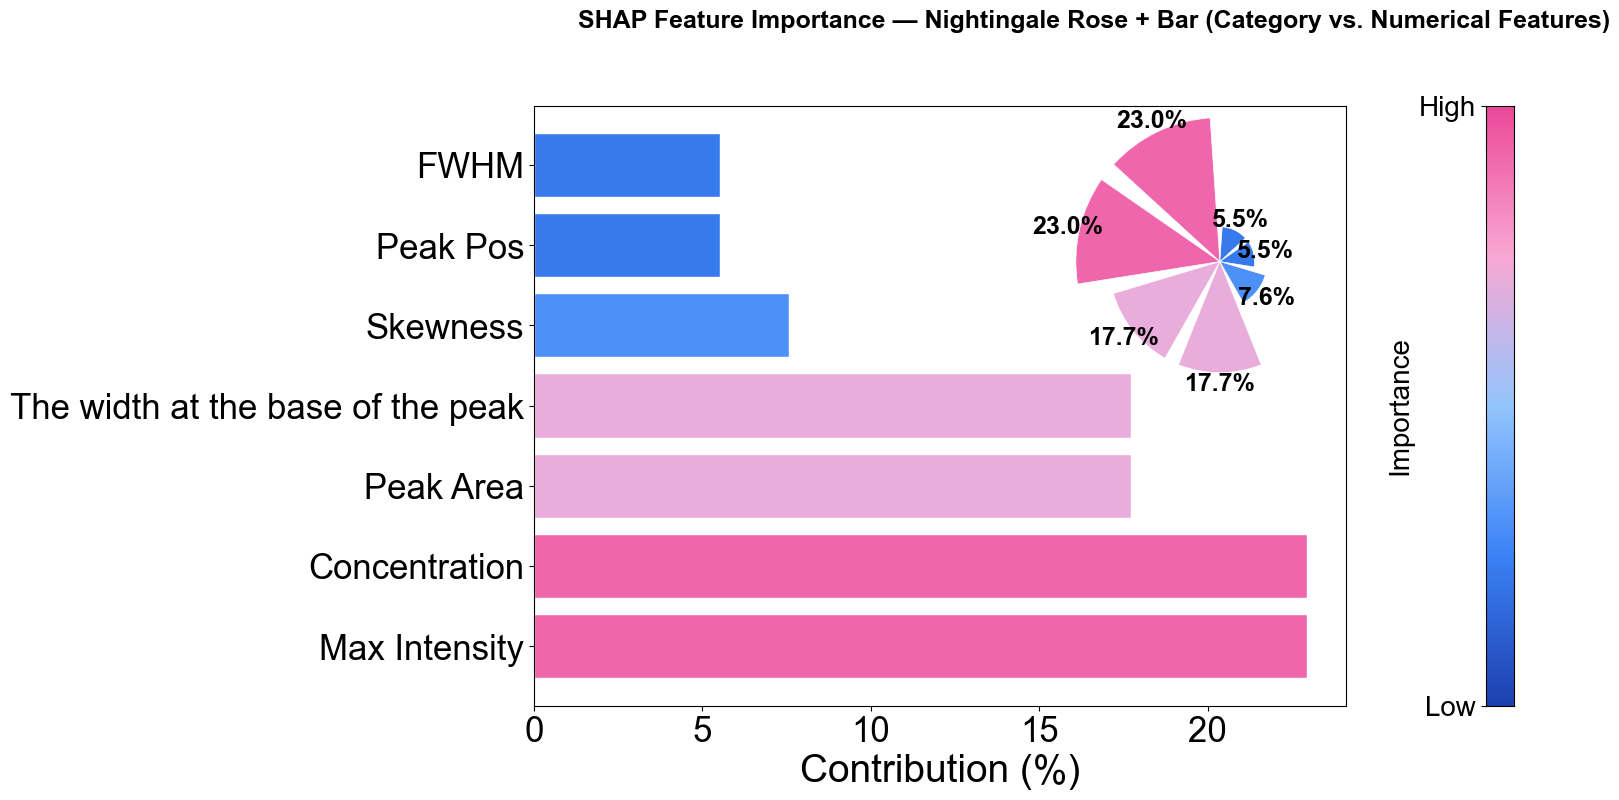

In [20]:
# ==========================================
# SHAP 特征重要性分析 + 南丁格尔玫瑰图
# 基于本 notebook 的 df 与 RandomForest
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 蓝到粉配色：Low=蓝色，High=粉色，与其他模块风格一致
_cmap_blue_pink = LinearSegmentedColormap.from_list('blue_pink', ['#1e40af', '#3b82f6', '#93c5fd', '#f9a8d4', '#ec4899'])
try:
    plt.colormaps.register(_cmap_blue_pink)
except Exception:
    pass

# 确保你已运行上一格安装 SHAP：!python -m pip install shap
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 重新划分（避免依赖其它单元格的变量状态）
X = df.drop(columns=['Category']).copy()
y = df['Category'].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 训练随机森林（用于 SHAP TreeExplainer）
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# 计算 SHAP 值（若是二分类，会返回 list；取正类索引 1）
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values

feature_names = list(X.columns)
n_features = len(feature_names)
mean_abs_shap = np.asarray(np.mean(np.abs(shap_values_pos), axis=0)).flatten()
if len(mean_abs_shap) > n_features:
    mean_abs_shap = mean_abs_shap[:n_features]
elif len(mean_abs_shap) < n_features:
    mean_abs_shap = np.pad(mean_abs_shap.astype(float), (0, n_features - len(mean_abs_shap)), constant_values=0)
order = np.atleast_1d(np.argsort(mean_abs_shap)[::-1]).astype(int)
sorted_feature_names = [feature_names[int(i)] for i in order]
sorted_shap_values = mean_abs_shap[order]


def plot_nightingale_rose_with_bars(sorted_feature_names, sorted_shap_values, add_colorbar=True, cmap_name='blue_pink'):
    total = float(np.sum(np.abs(sorted_shap_values)))
    if total == 0:
        raise ValueError('All SHAP values are zero; cannot compute percentages.')

    contribution_percentages = np.abs(sorted_shap_values) / total * 100
    n = len(sorted_shap_values)

    width = 2 * np.pi / n
    angles = np.linspace(np.pi / 2, np.pi / 2 + 2 * np.pi, n, endpoint=False) + width / 2

    # 0%-25% 贡献度映射为蓝→粉渐变（0%=蓝，25%=粉），而非单色蓝的深浅
    CONTRIBUTION_MAX_PCT = 25.0
    norm = np.clip(contribution_percentages / CONTRIBUTION_MAX_PCT, 0, 1)
    try:
        cmap = _cmap_blue_pink if cmap_name == 'blue_pink' else plt.colormaps[cmap_name]
    except Exception:
        cmap = _cmap_blue_pink if cmap_name == 'blue_pink' else plt.cm.get_cmap(cmap_name)
    colors = [cmap(v) for v in norm]

    # 组合成一张图：横向条形图为主，玫瑰图在其右上角空白处，颜色条在右侧注释边缘
    fig = plt.figure(figsize=(14, 8))
    # 主图：横向条形图（左侧与中部，右侧留出颜色条位置，留足边距避免字与边缘重叠）
    ax_bars = fig.add_axes([0.10, 0.15, 0.58, 0.75])
    y_pos = np.arange(n)[::-1]
    ax_bars.barh(y_pos, contribution_percentages, color=colors, edgecolor='white')
    ax_bars.set_yticks(y_pos)
    ax_bars.set_yticklabels(sorted_feature_names, fontsize=30)
    ax_bars.set_xlabel('Contribution (%)', fontsize=28)
    ax_bars.tick_params(axis='both', labelsize=25)
    ax_bars.invert_yaxis()

    # 玫瑰图：放在横向条形图右上角空白处（inset）
    ax_rose = fig.add_axes([0.40, 0.48, 0.38, 0.45], projection='polar')
    ax_rose.bar(
        angles,
        contribution_percentages,
        width=width * 0.85,
        align='center',
        color=colors,
        edgecolor='white',
        linewidth=0.5,
    )
    for a, p in zip(angles, contribution_percentages):
        ax_rose.text(a, p + max(contribution_percentages) * 0.08, f'{p:.1f}%', ha='center', va='center', fontsize=18, fontweight='bold')
    ax_rose.set_xticks([])
    ax_rose.set_ylim(0, max(contribution_percentages) * 1.25)
    ax_rose.set_yticks([])
    ax_rose.set_facecolor('none')
    ax_rose.spines['polar'].set_visible(False)

    # 颜色条：放在右侧注释边缘
    if add_colorbar:
        cbar_ax = fig.add_axes([0.78, 0.15, 0.02, 0.75])
        gradient = np.linspace(1, 0, 256).reshape(-1, 1)
        cbar_ax.imshow(gradient, aspect='auto', cmap=cmap, extent=[0, 1, 0, 1])
        cbar_ax.set_xticks([])
        cbar_ax.set_yticks([0, 1])
        cbar_ax.set_yticklabels(['Low', 'High'], fontsize=20)
        cbar_ax.set_ylabel('Importance', fontsize=20)
    fig.suptitle('SHAP Feature Importance — Nightingale Rose + Bar (Category vs. Numerical Features)', fontsize=18, fontweight='bold', y=1.02, ha='center')
    return fig, ax_rose

fig, _ = plot_nightingale_rose_with_bars(sorted_feature_names, sorted_shap_values, cmap_name='blue_pink')
plt.show()

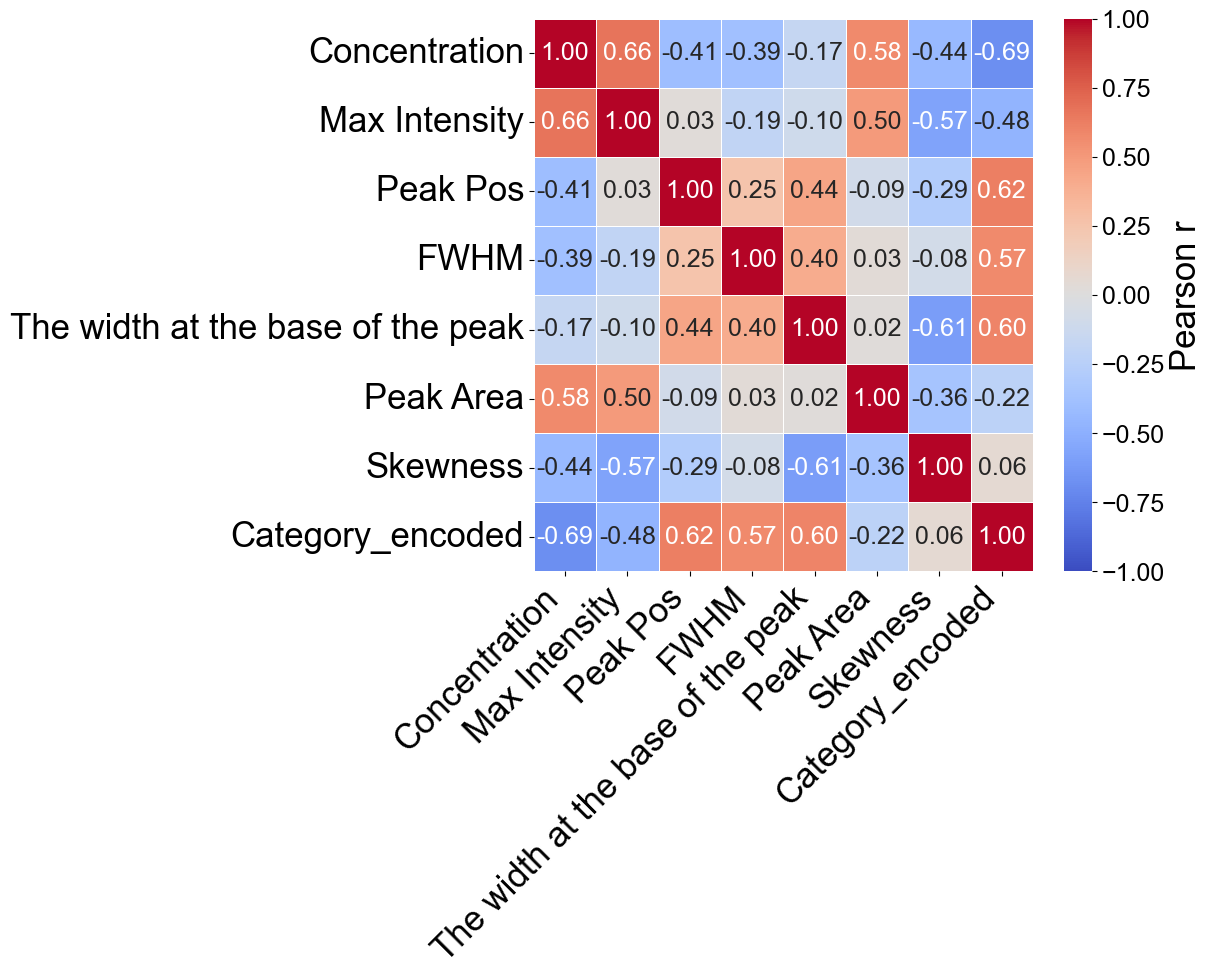

In [21]:
# ==========================================
# 5. 分类目标与全部数值特征两两相关性的热图（Pearson）
# ==========================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 全局设置字体为 Arial（前提是系统已安装 Arial）
rcParams['font.family'] = 'Arial'

# 复制一份数据，并将类别变量编码成数值，便于统一计算相关性
corr_df = df.copy()
# 将 Category 编码为 0,1,...（如果已经是数值，这一步会自动保持原值）
corr_df['Category_encoded'], _ = pd.factorize(corr_df['Category'])

# 只保留数值型列来计算相关系数矩阵
numeric_df = corr_df.select_dtypes(include=[np.number])

# 计算皮尔逊相关系数矩阵
corr_matrix = numeric_df.corr(method='pearson')

plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    fmt='.2f',
    annot_kws={'size': 18},
    cbar_kws={"label": "Pearson r"}
)
# 单独控制 colorbar 的字体大小
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=18)
cbar.set_label('Pearson r', size=25)

plt.title('',
          fontsize=24, fontweight='bold', fontfamily='Arial')
plt.xticks(rotation=45, ha='right', fontsize=25, fontfamily='Arial')
plt.yticks(fontsize=25, fontfamily='Arial')
plt.tight_layout(pad=1.5)
plt.show()

In [22]:
# ==========================================
# 6. 防数据泄露的“标准化 + 正则化”建模（Pipeline + 交叉验证）
#    - 所有拟合(标准化/调参)只在训练集及其CV折内完成
#    - 测试集仅用于最终一次评估
# ==========================================


# 备注：如果你怀疑“同一批次/同一浓度/同一实验条件”的样本高度相似导致“看似泄露”，
# 需要用 GroupKFold / GroupShuffleSplit 按组划分（例如按 Concentration 或样本ID分组）。

Accuracy comparison of three classifiers (Train vs Test)
              Model  Train Accuracy  Test Accuracy
                SVM          0.9844         1.0000
      Random Forest          1.0000         1.0000
Logistic Regression          0.9844         1.0000


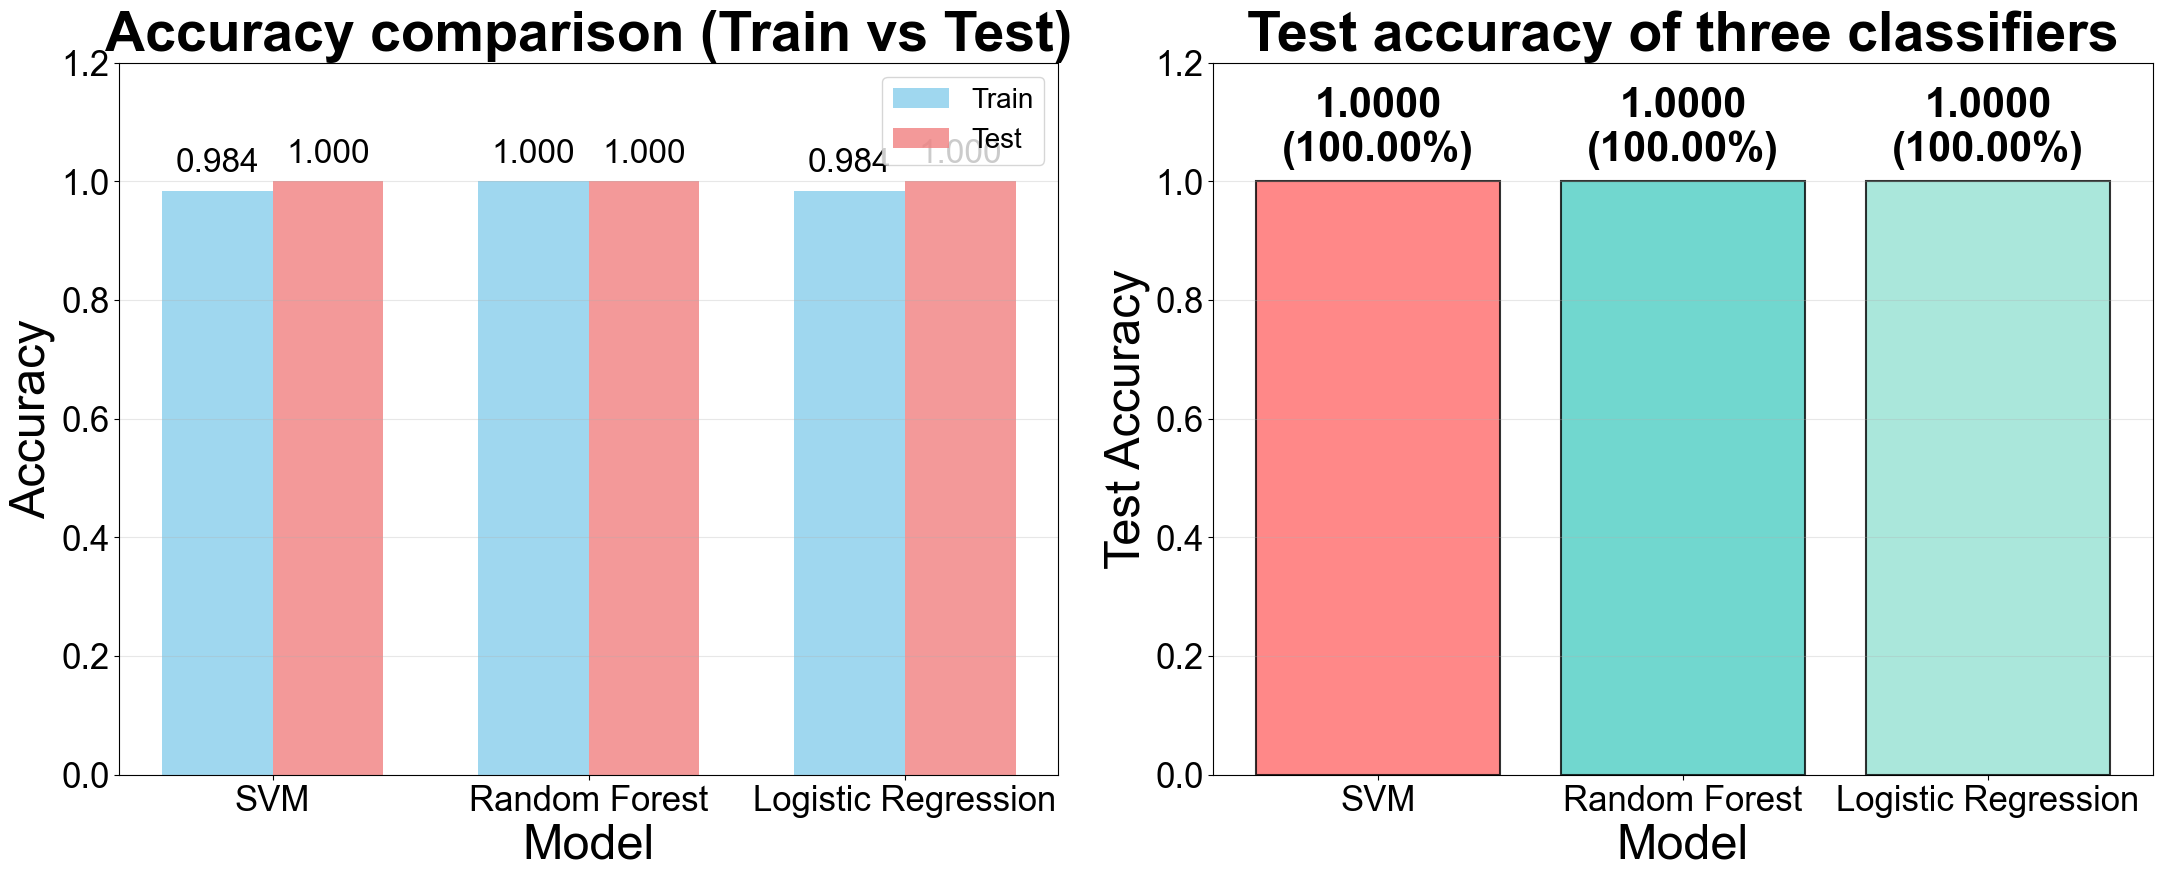


Best model: SVM
Best test accuracy: 1.0000 (100.00%)


In [23]:


# Logistic Regression (use best estimator from GridSearchCV)
lr_train_acc = accuracy_score(y_train, grid_lr.best_estimator_.predict(X_train))
lr_test_acc = accuracy_score(y_test, y_pred_lr)

# SVM (best estimator)
svc_train_acc = accuracy_score(y_train, grid_svc.best_estimator_.predict(X_train))
svc_test_acc = accuracy_score(y_test, y_pred_svc)

# Random Forest (simple baseline)
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train, y_train)
rf_train_acc = accuracy_score(y_train, rf_clf.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf_clf.predict(X_test))

results = {
    'Model': ['SVM', 'Random Forest', 'Logistic Regression'],
    'Train Accuracy': [svc_train_acc, rf_train_acc, lr_train_acc],
    'Test Accuracy': [svc_test_acc, rf_test_acc, lr_test_acc]
}

results_df = pd.DataFrame(results)
print("=" * 50)
print("Accuracy comparison of three classifiers (Train vs Test)")
print("=" * 50)
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Visualization: accuracy comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

x_pos = np.arange(len(results['Model']))
width = 0.35

# Train vs Test accuracy (grouped bars)
ax1.bar(x_pos - width/2, results['Train Accuracy'], width, label='Train', alpha=0.8, color='skyblue')
ax1.bar(x_pos + width/2, results['Test Accuracy'], width, label='Test', alpha=0.8, color='lightcoral')
ax1.set_xlabel('Model', fontsize=35)
ax1.set_ylabel('Accuracy', fontsize=35)
ax1.set_title('Accuracy comparison (Train vs Test)', fontsize=40, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(results['Model'])
ax1.set_ylim([0, 1.2])
ax1.legend(fontsize=20)
ax1.tick_params(axis='both', labelsize=25)
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, (train_acc, test_acc) in enumerate(zip(results['Train Accuracy'], results['Test Accuracy'])):
    ax1.text(i - width/2, train_acc + 0.02, f'{train_acc:.3f}', ha='center', va='bottom', fontsize=24)
    ax1.text(i + width/2, test_acc + 0.02, f'{test_acc:.3f}', ha='center', va='bottom', fontsize=24)

# Test accuracy only (single bar chart)
colors = ['#FF6B6B', '#4ECDC4', '#95E1D3']
bars = ax2.bar(results['Model'], results['Test Accuracy'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Model', fontsize=35)
ax2.set_ylabel('Test Accuracy', fontsize=35)
ax2.set_title('Test accuracy of three classifiers', fontsize=40, fontweight='bold')
ax2.tick_params(axis='both', labelsize=25)
ax2.set_ylim([0, 1.2])
ax2.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, results['Test Accuracy']):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{acc:.4f}\n({acc*100:.2f}%)',
             ha='center', va='bottom', fontsize=30, fontweight='bold')

plt.tight_layout(pad=1.5)
plt.savefig('classification_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

best_index = int(np.argmax(results['Test Accuracy']))
print(f"\nBest model: {results['Model'][best_index]}")
print(f"Best test accuracy: {max(results['Test Accuracy']):.4f} ({max(results['Test Accuracy'])*100:.2f}%)")



In [25]:
# （已移动到 SHAP 图代码前）
# 这个单元格可忽略。

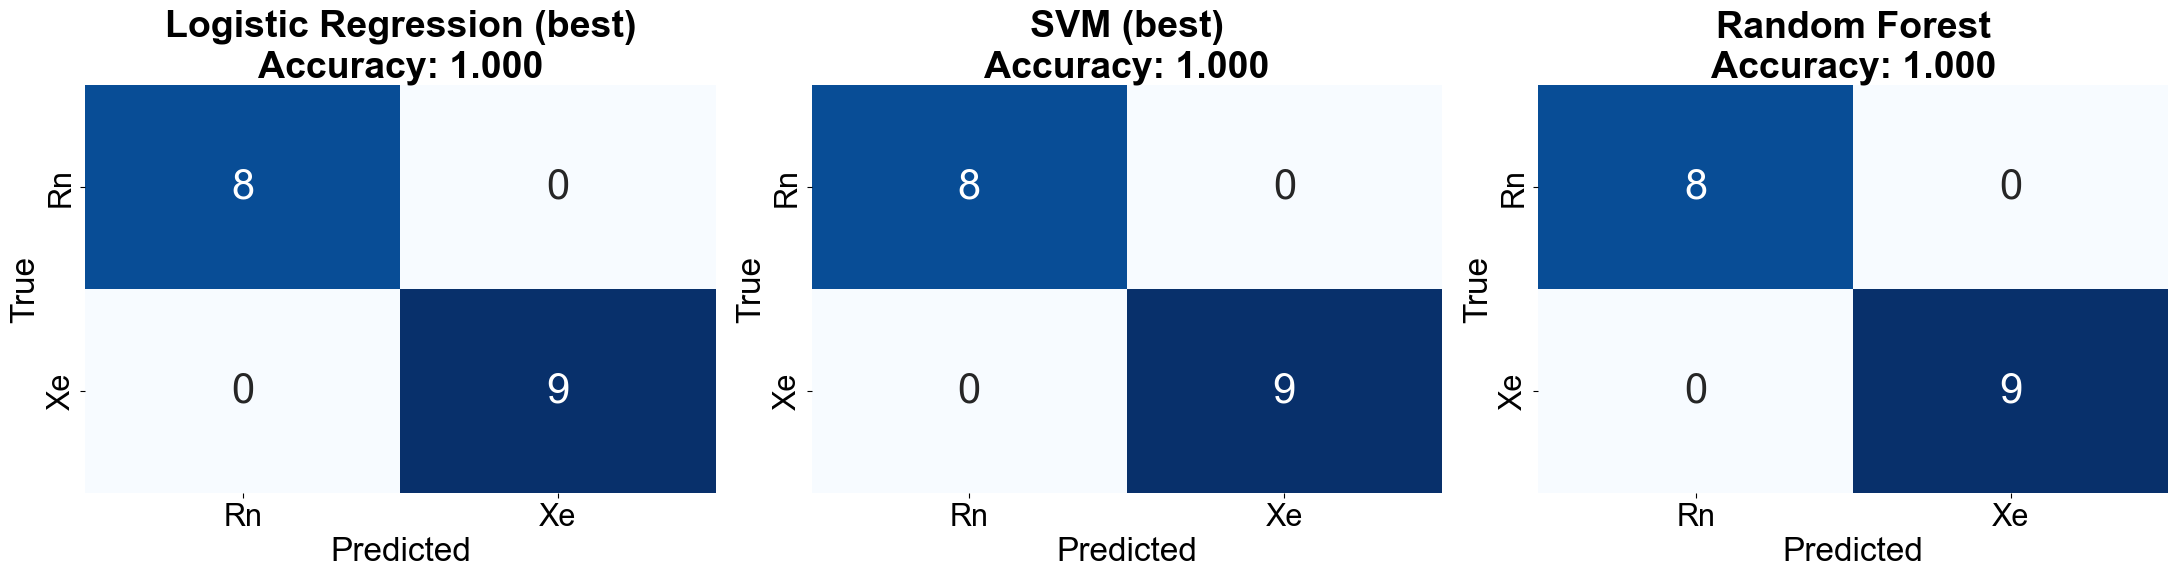

In [26]:
# === Confusion matrices on the test set (LR, SVM, RF) ===
# 说明：此单元格可独立运行；若前面预测变量不存在，会自动重新训练/预测。

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score


def _ensure_preds():
    global X, y, X_train, X_test, y_train, y_test
    global y_pred_lr, y_pred_svc, rf_clf

    # 基础数据
    if 'df' not in globals():
        raise NameError("df is not defined. Please run the data loading cell first.")

    X = df.drop(columns=['Category']).copy()
    y = df['Category'].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.8,
        random_state=42,
        stratify=y,
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # LR（带标准化 + 正则）
    pipe_lr = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=5000)),
    ])
    param_lr = {
        'clf__solver': ['saga'],
        'clf__penalty': ['l1', 'l2'],
        'clf__C': np.logspace(-3, 3, 13),
        'clf__class_weight': [None, 'balanced'],
    }
    grid_lr = GridSearchCV(pipe_lr, param_grid=param_lr, cv=cv, n_jobs=-1, scoring='accuracy')
    grid_lr.fit(X_train, y_train)
    y_pred_lr = grid_lr.predict(X_test)

    # SVM（带标准化，C 调参）
    pipe_svc = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC()),
    ])
    param_svc = [
        {
            'clf__kernel': ['linear'],
            'clf__C': np.logspace(-3, 3, 13),
            'clf__class_weight': [None, 'balanced'],
        },
        {
            'clf__kernel': ['rbf'],
            'clf__C': np.logspace(-3, 3, 13),
            'clf__gamma': ['scale', 'auto'],
            'clf__class_weight': [None, 'balanced'],
        },
    ]
    grid_svc = GridSearchCV(pipe_svc, param_grid=param_svc, cv=cv, n_jobs=-1, scoring='accuracy')
    grid_svc.fit(X_train, y_train)
    y_pred_svc = grid_svc.predict(X_test)

    # RF
    rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
    rf_clf.fit(X_train, y_train)


# 若预测变量不存在，自动补齐（必须先运行第 1 格加载 df，再运行第 2 格或本格）
if 'y_pred_lr' not in globals() or 'y_pred_svc' not in globals() or 'rf_clf' not in globals():
    _ensure_preds()

cm_models = {
    'Logistic Regression (best)': y_pred_lr,
    'SVM (best)': y_pred_svc,
    'Random Forest': rf_clf.predict(X_test),
}

labels = sorted(np.unique(y_test))

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, (name, y_pred) in zip(axes, cm_models.items()):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        annot_kws={'size': 30},
    )
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.3f}', fontsize=27, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=24)
    ax.set_ylabel('True', fontsize=24)
    ax.tick_params(axis='both', labelsize=22)

plt.tight_layout(pad=1.5)
plt.savefig('confusion_matrices_test.png', dpi=300, bbox_inches='tight')
plt.show()


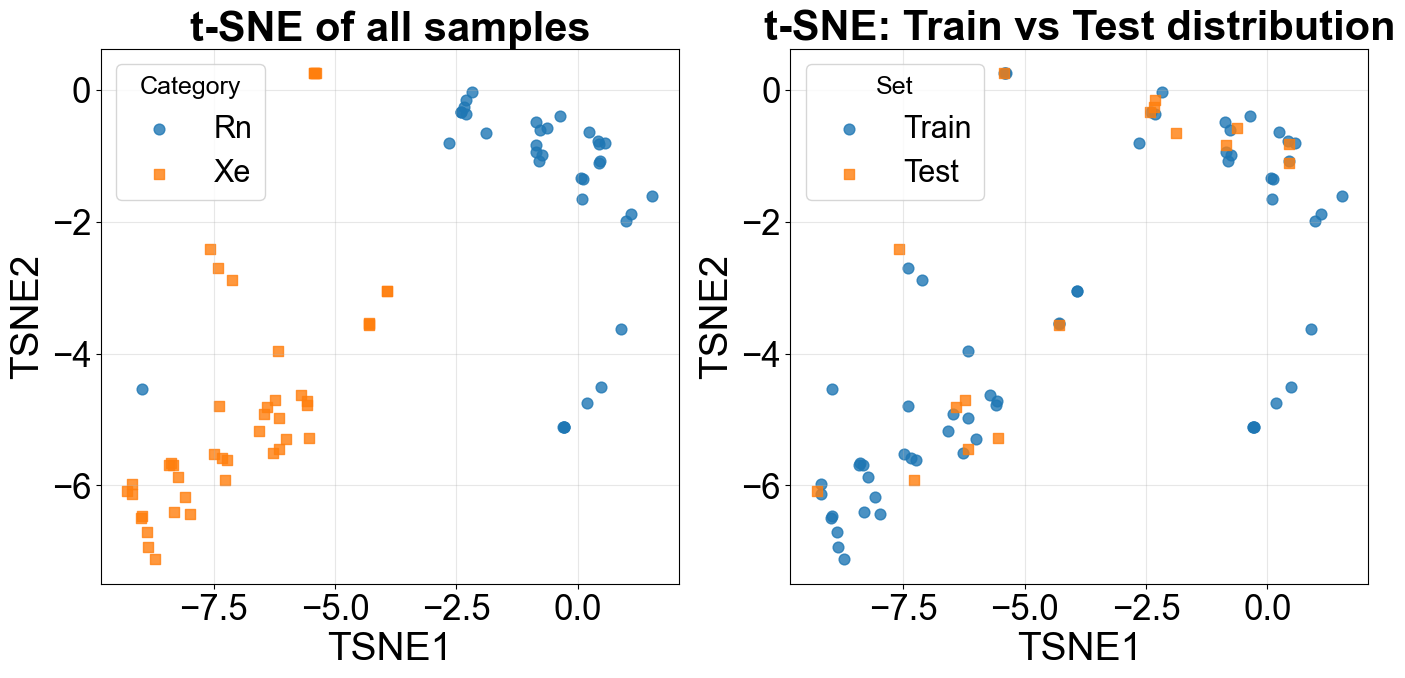

In [27]:
# ==========================================
# 7. t-SNE visualization of samples (train vs test) to inspect overfitting
# ==========================================

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Use all numeric features
X_all = df.drop('Category', axis=1)
y_all = df['Category']

# Reuse the existing train/test split indices
train_idx = X_train.index
test_idx = X_test.index

# Standardize before t-SNE (recommended)
scaler_tsne = StandardScaler()
X_all_scaled = scaler_tsne.fit_transform(X_all)

# 2D t-SNE embedding
tsne = TSNE(
    n_components=2,
    perplexity=min(30, max(5, len(X_all) // 3)),
    learning_rate='auto',
    init='random',
    random_state=42
)
X_embedded = tsne.fit_transform(X_all_scaled)

# Build a DataFrame for plotting
vis_df = pd.DataFrame({
    'TSNE1': X_embedded[:, 0],
    'TSNE2': X_embedded[:, 1],
    'Category': y_all.values,
    'Set': ['Train' if idx in train_idx else 'Test' for idx in X_all.index],
})

plt.figure(figsize=(14, 7))

# Left: colored by true class
plt.subplot(1, 2, 1)
for cls, marker in zip(sorted(vis_df['Category'].unique()), ['o', 's', '^', 'D']):
    sub = vis_df[vis_df['Category'] == cls]
    plt.scatter(sub['TSNE1'], sub['TSNE2'], label=str(cls), alpha=0.8, s=60, marker=marker)
plt.title('t-SNE of all samples', fontsize=30, fontweight='bold')
plt.xlabel('TSNE1', fontsize=28)
plt.ylabel('TSNE2', fontsize=28)
plt.legend(title='Category', fontsize=22, title_fontsize=18)
plt.tick_params(axis='both', labelsize=25)
plt.grid(alpha=0.3)

# Right: highlight Train vs Test (to visually inspect potential overfitting)
plt.subplot(1, 2, 2)
markers = {'Train': 'o', 'Test': 's'}
colors = {'Train': '#1f77b4', 'Test': '#ff7f0e'}
for subset in ['Train', 'Test']:
    sub = vis_df[vis_df['Set'] == subset]
    plt.scatter(
        sub['TSNE1'],
        sub['TSNE2'],
        c=colors[subset],
        marker=markers[subset],
        alpha=0.8,
        s=60,
        label=subset,
    )
plt.title('t-SNE: Train vs Test distribution', fontsize=30, fontweight='bold')
plt.xlabel('TSNE1', fontsize=28)
plt.ylabel('TSNE2', fontsize=28)
plt.legend(title='Set', fontsize=22, title_fontsize=18)
plt.tick_params(axis='both', labelsize=25)
plt.grid(alpha=0.3)

plt.tight_layout(pad=1.5)
plt.savefig('tsne_train_test.png', dpi=300, bbox_inches='tight')
plt.show()

